In [15]:
import uproot
import matplotlib.pyplot as plt
import seaborn
import numpy as np
import math
from scipy.fft import fft, fftfreq
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

import os
from plotly.subplots import make_subplots
from plotly import tools
import plotly.offline as pyo
import sys
from tqdm import tqdm

In [23]:
files =uproot.open(f"/Users/danielcarber/Documents/SBND/Noise Analysis/data/fft_output_run14784_20.root")
files1 =uproot.open(f"/Users/danielcarber/Documents/SBND/Noise Analysis/data/noise_output_coh_run14784_int_fft.root")
print(files['tpc_noise;3'].keys())
print(files.keys()[0])

['avg_FFT']
tpc_noise;3


In [28]:
raw_rms = files['tpc_noise;3']['avg_FFT'].array()
raw_rms1 = files1['tpc_noise;3']['avg_FFT'].array()
print(raw_rms[1709*1:1709*2])
#raw_rms = files['tpc_noise;2']['avg_FFT'].array()
print(len(raw_rms)/1709)
FFTs_list = {}
FFTs_list1 = {}
#print((FFTs_list[0:1709]))

[0, 4.4e+04, 4.44e+04, 4.53e+04, 4.5e+04, ..., 5.1e+03, 5e+03, 4.99e+03, 298]
11264.0


In [29]:
channel=-1
FFTs_list['total'] = [0]*1709
for i in tqdm(range(11264)):
    
    if raw_rms[1709*(i+1)-1]==0:
        FFTs_list[f'{i}'] = 'skip'
        continue
    FFTs_list[f'{i}'] =list(raw_rms[i*1709:(i+1)*1709]/raw_rms[1709*(i+1)-1])
    #print(raw_rms[1708])
    #if i%1709 == 0:
    #    
    #    #print(i,":",raw_rms[i])
    #    channel+=1
    #    FFTs_list[f'{channel}'] =[raw_rms[]]
    #else:
    #    FFTs_list[f'{channel}'].append(raw_rms[i])
print(FFTs_list['0'][-1])
skipped = 0
for channel in tqdm(range(0,11264,1)):
    if FFTs_list[f'{channel}'] == 'skip':
        skipped +=1
        continue
    FFTs_list[f'total'] =[FFTs_list[f'total'][j] + FFTs_list[f'{channel}'][j] for j in range(len(FFTs_list[f'{channel}']))]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11264/11264 [00:02<00:00, 4112.19it/s]


1.0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11264/11264 [00:04<00:00, 2363.13it/s]


In [30]:
channel=-1
FFTs_list1['total'] = [0]*1709
for i in tqdm(range(11264)):
    
    if raw_rms1[1709*(i+1)-1]==0:
        FFTs_list1[f'{i}'] = 'skip'
        continue
    FFTs_list1[f'{i}'] =list(raw_rms1[i*1709:(i+1)*1709]/raw_rms1[1709*(i+1)-1])
    #print(raw_rms[1708])
    #if i%1709 == 0:
    #    
    #    #print(i,":",raw_rms[i])
    #    channel+=1
    #    FFTs_list[f'{channel}'] =[raw_rms[]]
    #else:
    #    FFTs_list[f'{channel}'].append(raw_rms[i])
print(FFTs_list1['0'][-1])
skipped = 0
for channel in tqdm(range(0,11264,1)):
    if FFTs_list1[f'{channel}'] == 'skip':
        skipped +=1
        continue
    FFTs_list1[f'total'] =[FFTs_list1[f'total'][j] + FFTs_list1[f'{channel}'][j] for j in range(len(FFTs_list1[f'{channel}']))]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11264/11264 [00:02<00:00, 4075.12it/s]


1.0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11264/11264 [00:04<00:00, 2353.97it/s]


In [31]:
print((raw_rms[100]))
print(len((raw_rms)))
df = {'total':[0]*1709}
#print(df['total'])
channel = -1
for i in range(0,1709,1):
    if i%1708 == 0:
        channel +=1
        df[f'{channel}'] = [raw_rms[i]]  
        df['total'][0] +=raw_rms[i]
    else:
        df[f'{channel}'].append(raw_rms[i])
        df['total'][i%1708] +=raw_rms[i]

48252.91
19250176


In [32]:
np.divide(df['total'],500)

array([  0.598     , 111.02567969, 105.52371875, ...,   9.7971084 ,
         9.86200684,   0.        ])

ValueError: x and y must have same first dimension, but have shapes (1708,) and (1709,)

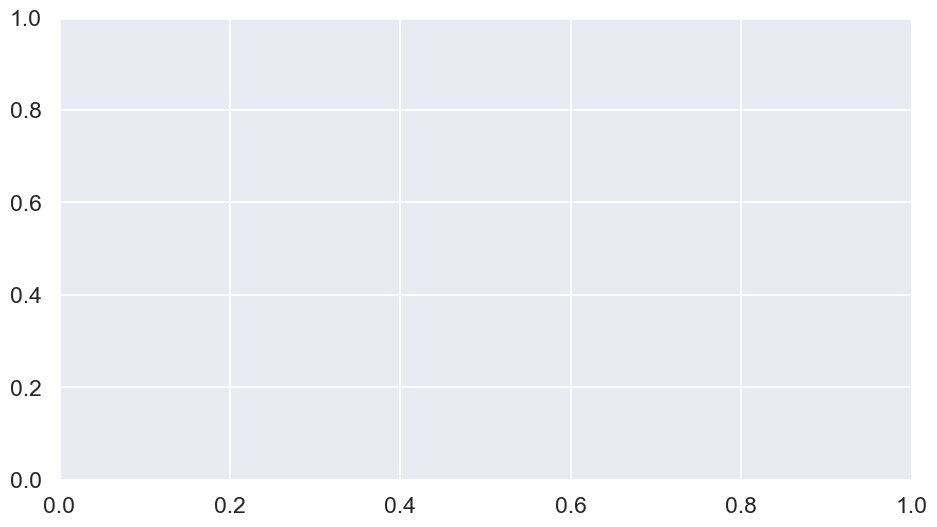

In [7]:
seaborn.set(rc={
    'figure.figsize':(11, 6),
})
seaborn.set_context('talk')
freq = list(range(len(FFTs_list['100'])-1))
freq = (np.add(freq,.5))*2/3415
#plt.plot(range(len(ADC_array[0][0])),ADC_array[0][4231])
#plt.hist(signal_diff_coll,range = [0,300],bins = 100, label = "Coll")
#plt.hist(signal_diff_ind_1,range = [0,300],bins = 100,alpha = .6, label = "Ind 1")
#plt.hist(signal_diff_ind_2,range = [0,300],bins = 100, alpha = .2,label = "Ind 2")
#plt.scatter(df['channel_id'],df['raw_rms'],alpha = 1, label = "RMS before shift",s = 10)
#plt.scatter(df_2['channel_id'],df_2['raw_rms'],alpha = 1, label = "RMS after shift",s = 10)
plt.plot(freq,FFTs_list['0'] ,alpha = .8, label = "RMS of Channels w/ signals")

#plt.hist(df['Time_diff'], range=[0, 2000],bins=50,alpha =1, label = "Time difference")
#plt.hist(selection['reco_dedx'][ep_mask_e], range=[0, 10], alpha = .4,bins=50,label = "Reco Electrons")
#plt.ylim(0,250)
plt.xlim(0,1)
#plt.yscale("log")
#plt.legend(loc = "upper right")
plt.xlabel("MHz")
plt.ylabel("RMS")
plt.title("RMS of Run 10775")
plt.show()
#plt.savefig('dedx_4000_events.png')

In [38]:
color = ['red','green','blue']
run_number='14784'
fig = make_subplots(rows=1,cols =1,subplot_titles = ('Intrinsic FFT Spectrum',))
fig.add_trace(go.Scatter(x=freq,y = np.divide(FFTs_list['total'][0:1708],11264-skipped),marker_color = color[0],opacity = 2/(1+1),name = f'Run {run_number}'),row = 1, col = 1)
fig.add_trace(go.Scatter(x=freq,y = np.divide(FFTs_list1['total'][0:1708],11264-skipped),marker_color = color[1],opacity = 2/(1+1),name = f'Run {run_number} Intrinsic'),row = 1, col = 1)

fig.update_xaxes(title_text = "Frequency [MHz]",row = 1, col = 1)
fig.update_yaxes(title_text = "Magnitude [ADC/0.59kHz]",row = 1, col = 1)
fig.update_layout(xaxis = dict(tickmode = 'linear',dtick = .1,range= [0,1]))
fig.update_layout(height = 600, width = 900,showlegend = True)
fig.update_annotations(font_size=36)
fig
fig.update_layout(font = dict(size=20),legend=dict(
    yanchor="top",
    y=0.99,
    xanchor="left",
    x=0.64,
    bgcolor="LightSteelBlue",
        bordercolor="Black",
))

fig.add_annotation(dict(font = dict(size = 25,color="Black",)),xshift= 250,yshift=100,text = f"SBND<br>Preliminary Data",showarrow = False)
fig.write_image(f'/Users/danielcarber/Documents/SBND/Noise Analysis/Plots/SBND_TPC_FFT.png')
fig.write_image(f'/Users/danielcarber/Documents/SBND/Noise Analysis/Plots/SBND_TPC_FFT.pdf')
fig.show()

In [9]:
freq[3]-freq[2]

0.0005856515373352856

In [10]:
fig = make_subplots(rows=1,cols =1)
#mask = Noise_df['wire_plane'] == 'UB'
#median = np.median(Noise_df['Raw_rms'][mask])
#mean = np.mean(Noise_df['Raw_rms'][mask])
#fig.add_trace(go.Histogram(x=Noise_df['Raw_rms'][mask],marker_color = 'red',xbins=dict(start = median - 5,end = median+5,size=.05)),row = 1, col =2)
fig.add_trace(go.Scatter(x=freq,y = np.divide(df['total'],1),marker_color = 'red'),row = 1, col = 1)
fig.update_layout(xaxis = dict(range = [1*0,.996*1]),yaxis = dict(range = [0,250]))
fig.show()
#fig.add_annotation(dict(font = dict(size = 10),xshift= 180,yshift=120,text = f"Mean RMS:{mean:.2f}",showarrow = False),row =1,col=2)
#fig.add_annotation(dict(font = dict(size = 10),xshift= 180,yshift=110,text = f"Median RMS:{median:.2f}",showarrow = False),row =1,col=2)

